In [1]:
import os

os.environ["A3_API_KEY"] = "06654134"

if os.getenv("A3_API_KEY", "") == "":
    raise ValueError(
        "A3_API_KEY is not set. Please set it in your environment variables or use `os.environ['A3_API_KEY'] = 'your-8-digit-student-id'`"
    )

In [168]:
import time
import rich

from cs336_scaling.client import (
    get_budget,
    get_experiment,
    list_experiments,
    save_final_submission,
    submit_experiment,
)
from cs336_scaling.training.model.basic_model import BasicTransformerConfig
from cs336_scaling.training.optimizer import AdamWConfig, WarmupCosineDecay
from cs336_scaling.training.training_config import TrainingConfig

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from scipy.optimize import curve_fit

In [3]:
get_budget()

BudgetSummary(used_seconds=0.0, remaining_seconds=43200.0, total_budget_seconds=43200.0)

In [7]:
def compute_isoflops_vals(training_config):
    cfg = training_config.architecture_config
    N = 12 * cfg.num_hidden_layers * cfg.hidden_size ** 2
    D = training_config.total_train_tokens
    C = 6 * N * D
    return {
        "N": N,
        "D": D,
        "C": C,
    }

In [5]:
# define our experiment config
training_config = TrainingConfig(
    architecture_config=BasicTransformerConfig(
        attention_bias=False,
        head_dim=64,
        hidden_size=448,
        intermediate_size=1280,
        num_attention_heads=7,
        num_hidden_layers=9,
        num_key_value_heads=7,
        rms_norm_eps=1e-6,
        rope_theta=1_000_000,
        tie_word_embeddings=False,
        dtype="bfloat16",
        vocab_size=32_000,
    ),
    optimizer_config=AdamWConfig(
        lr_scheduler=WarmupCosineDecay(
            peak_value=3e-4,
            final_lr_frac=0.1,
            warmup_frac=0.05,
            init_value=0.0,
        ),
        weight_decay=1e-2,
        beta1=0.9,
        beta2=0.95,
        eps=1e-8,
        eps_root=1e-8,
        grad_clip_norm=1.0,
    ),
    train_batch_size=128,
    val_batch_size=32,
    n_evals=16,
    total_train_tokens=8_388_608,
    max_runtime_seconds=60.0,
    model_seed=0,
)
rich.print(training_config)

TrainingConfig(
    architecture_config=BasicTransformerConfig(
        attention_bias=False,
        head_dim=64,
        hidden_size=448,
        intermediate_size=1280,
        num_attention_heads=7,
        num_hidden_layers=9,
        num_key_value_heads=7,
        rms_norm_eps=1e-06,
        rope_theta=1000000,
        tie_word_embeddings=False,
        dtype='bfloat16',
        vocab_size=32000
    ),
    optimizer_config=AdamWConfig(
        lr_scheduler=WarmupCosineDecay(peak_value=0.0003, final_lr_frac=0.1, warmup_frac=0.05, init_value=0.0),
        weight_decay=0.01,
        beta1=0.9,
        beta2=0.95,
        eps=1e-08,
        eps_root=1e-08,
        grad_clip_norm=1.0
    ),
    train_batch_size=128,
    val_batch_size=32,
    n_evals=16,
    total_train_tokens=8388608,
    max_runtime_seconds=60.0,
    model_seed=0
)

In [8]:
print(compute_isoflops_vals(training_config))

{'N': 21676032, 'D': 8388608, 'C': 1090990412660736}


In [9]:
submit_result = submit_experiment(training_config)
submit_result

SubmitResponse(experiment_id=1213, budget_summary=BudgetSummary(used_seconds=60.0, remaining_seconds=43140.0, total_budget_seconds=43200.0))

In [10]:
rich.print(list_experiments())

[
    ExperimentResponse(
        experiment_id=1213,
        training_config=TrainingConfig(
            architecture_config=BasicTransformerConfig(
                attention_bias=False,
                head_dim=64,
                hidden_size=448,
                intermediate_size=1280,
                num_attention_heads=7,
                num_hidden_layers=9,
                num_key_value_heads=7,
                rms_norm_eps=1e-06,
                rope_theta=1000000,
                tie_word_embeddings=False,
                dtype='bfloat16',
                vocab_size=32000
            ),
            optimizer_config=AdamWConfig(
                lr_scheduler=WarmupCosineDecay(
                    peak_value=0.0003,
                    final_lr_frac=0.1,
                    warmup_frac=0.05,
                    init_value=0.0
                ),
                weight_decay=0.01,
                beta1=0.9,
                beta2=0.95,
                eps=1e-08,
                eps_root=1e-08,
                grad_clip_norm=1.0
            ),
            train_batch_size=128,
            val_batch_size=32,
            n_evals=16,
            total_train_tokens=8388608,
            max_runtime_seconds=60.0,
            model_seed=0
        ),
        status=RunningExperimentStatus(
            queued_at=datetime.datetime(2026, 5, 5, 3, 28, 47, 247039, tzinfo=TzInfo(0)),
            dispatched_at=datetime.datetime(2026, 5, 5, 3, 28, 48, 588032, tzinfo=TzInfo(0)),
            run_id='fc-01KQV2WRVG570F7CFAKGK3R8V6',
            val_losses=[],
            status_type='running'
        )
    )
]

In [13]:
rich.print(get_experiment(submit_result.experiment_id))

ExperimentResponse(
    experiment_id=1213,
    training_config=TrainingConfig(
        architecture_config=BasicTransformerConfig(
            attention_bias=False,
            head_dim=64,
            hidden_size=448,
            intermediate_size=1280,
            num_attention_heads=7,
            num_hidden_layers=9,
            num_key_value_heads=7,
            rms_norm_eps=1e-06,
            rope_theta=1000000,
            tie_word_embeddings=False,
            dtype='bfloat16',
            vocab_size=32000
        ),
        optimizer_config=AdamWConfig(
            lr_scheduler=WarmupCosineDecay(
                peak_value=0.0003,
                final_lr_frac=0.1,
                warmup_frac=0.05,
                init_value=0.0
            ),
            weight_decay=0.01,
            beta1=0.9,
            beta2=0.95,
            eps=1e-08,
            eps_root=1e-08,
            grad_clip_norm=1.0
        ),
        train_batch_size=128,
        val_batch_size=32,
        n_evals=16,
        total_train_tokens=8388608,
        max_runtime_seconds=60.0,
        model_seed=0
    ),
    status=CompletedExperimentStatus(
        queued_at=datetime.datetime(2026, 5, 5, 3, 28, 47, 247039, tzinfo=TzInfo(0)),
        dispatched_at=datetime.datetime(2026, 5, 5, 3, 28, 48, 588032, tzinfo=TzInfo(0)),
        run_id='fc-01KQV2WRVG570F7CFAKGK3R8V6',
        used_runtime_seconds=11.02544100099476,
        val_losses=[
            9.625,
            8.92578125,
            8.37890625,
            7.97265625,
            7.607421875,
            7.4453125,
            7.328125,
            7.291015625,
            7.25,
            7.22265625,
            7.208984375,
            7.19921875,
            7.193359375,
            7.189453125,
            7.189453125,
            7.189453125
        ],
        completed_at=datetime.datetime(2026, 5, 5, 3, 29, 22, 861912, tzinfo=TzInfo(0)),
        status_type='completed'
    )
)

In [14]:
get_budget()

BudgetSummary(used_seconds=11.02544100099476, remaining_seconds=43188.974558999005, total_budget_seconds=43200.0)

# Figure out FLOPs of the model

In [18]:
# Shared config
shared_optimizer = AdamWConfig(
    lr_scheduler=WarmupCosineDecay(peak_value=3e-4, final_lr_frac=0.1, warmup_frac=0.05, init_value=0.0),
    weight_decay=1e-2,
    beta1=0.9,
    beta2=0.95,
    eps=1e-8,
    eps_root=1e-8,
    grad_clip_norm=1.0,
)
shared_arch = dict(
    attention_bias=False,
    head_dim=64,
    rms_norm_eps=1e-6,
    rope_theta=1_000_000,
    tie_word_embeddings=False,
    dtype="bfloat16",
    vocab_size=32_000,
)
shared_training = dict(
    optimizer_config=shared_optimizer,
    train_batch_size=128,
    val_batch_size=32,
    n_evals=4,
    total_train_tokens=512 * 128 * 64,
    max_runtime_seconds=60.0,
    model_seed=0,
)

# Only the parts that differ per model size
model_sizes = [
    {
        "hidden_size": 256,
        "intermediate_size": 768,
        "num_attention_heads": 4,
        "num_hidden_layers": 6,
    },
    {
        "hidden_size": 768,
        "intermediate_size": 2048,
        "num_attention_heads": 12,
        "num_hidden_layers": 6,
    },
    {
        "hidden_size": 1024,
        "intermediate_size": 2816,
        "num_attention_heads": 16,
        "num_hidden_layers": 12,
    },
]

# Build configs
calibration_configs = []
for size in model_sizes:
    cfg = TrainingConfig(
        architecture_config=BasicTransformerConfig(
            **shared_arch,
            **size,
            num_key_value_heads=size["num_attention_heads"],
        ),
        **shared_training,
    )
    vals = compute_isoflops_vals(cfg)
    print(
        f"hidden={size['hidden_size']}, layers={size['num_hidden_layers']}, N={vals['N']}, D={vals['D']}, C={vals['C']}"
    )
    calibration_configs.append(cfg)

hidden=256, layers=6, N=4718592, D=4194304, C=118747255799808
hidden=768, layers=6, N=42467328, D=4194304, C=1068725302198272
hidden=1024, layers=12, N=150994944, D=4194304, C=3799912185593856


In [19]:
experiment_ids = []
for cfg in calibration_configs:
    result = submit_experiment(cfg)
    experiment_ids.append(result.experiment_id)
    print(f"Submitted experiment {result.experiment_id}, budget: {result.budget_summary}")

Submitted experiment 1227, budget: used_seconds=71.02544100099476 remaining_seconds=43128.974558999005 total_budget_seconds=43200.0
Submitted experiment 1228, budget: used_seconds=131.02544100099476 remaining_seconds=43068.974558999005 total_budget_seconds=43200.0
Submitted experiment 1229, budget: used_seconds=191.02544100099476 remaining_seconds=43008.974558999005 total_budget_seconds=43200.0


In [23]:
experiments = list_experiments()

for exp in experiments:
    if exp.status.status_type == "completed":
        vals = compute_isoflops_vals(exp.training_config)
        runtime = exp.status.used_runtime_seconds
        throughput = vals["C"] / runtime
        print(f"exp {exp.experiment_id}: N={vals['N']:.2e}, D={vals['D']:.2e}, C={vals['C']:.2e}, runtime={runtime:.2f}s, throughput={throughput:.2e} FLOP/s")

exp 1213: N=2.17e+07, D=8.39e+06, C=1.09e+15, runtime=11.03s, throughput=9.90e+13 FLOP/s
exp 1227: N=4.72e+06, D=4.19e+06, C=1.19e+14, runtime=2.65s, throughput=4.49e+13 FLOP/s
exp 1228: N=4.25e+07, D=4.19e+06, C=1.07e+15, runtime=5.88s, throughput=1.82e+14 FLOP/s
exp 1229: N=1.51e+08, D=4.19e+06, C=3.80e+15, runtime=13.19s, throughput=2.88e+14 FLOP/s


In [50]:
def make_training_config(model_size_dict, C, train_batch_size=128, n_evals=16):
    hidden = model_size_dict["hidden_size"]
    n_layers = model_size_dict["num_hidden_layers"]
    n_heads = model_size_dict["num_attention_heads"]
    
    N = 12 * n_layers * hidden ** 2
    D = C / (6 * N)
    
    # total_tokens must be divisible by 512 * batch_size * n_evals
    chunk = 512 * train_batch_size * n_evals
    total_tokens = max(chunk, round(D / chunk) * chunk)
    
    return TrainingConfig(
        architecture_config=BasicTransformerConfig(
            **shared_arch,
            **model_size_dict,
            num_key_value_heads=n_heads,
            intermediate_size=hidden * 4,
        ),
        optimizer_config=shared_optimizer,
        train_batch_size=train_batch_size,
        val_batch_size=32,
        n_evals=n_evals,
        total_train_tokens=total_tokens,
        max_runtime_seconds=7200,
        model_seed=0,
    )

In [51]:
# Only what differs per model size
model_sizes = {
    "5M":   {"hidden_size": 256,  "num_attention_heads": 4,  "num_hidden_layers": 8},
    "10M":  {"hidden_size": 320,  "num_attention_heads": 5,  "num_hidden_layers": 8},
    "20M":  {"hidden_size": 448,  "num_attention_heads": 7,  "num_hidden_layers": 8},
    "50M":  {"hidden_size": 640,  "num_attention_heads": 10, "num_hidden_layers": 10},
    "100M": {"hidden_size": 896,  "num_attention_heads": 14, "num_hidden_layers": 10},
    "200M": {"hidden_size": 1280, "num_attention_heads": 20, "num_hidden_layers": 10},
}

# Everything shared
shared_arch = dict(
    attention_bias=False,
    head_dim=64,
    rms_norm_eps=1e-6,
    rope_theta=1_000_000,
    tie_word_embeddings=False,
    dtype="bfloat16",
    vocab_size=32_000,
)

# Verify N values
for name, size in model_sizes.items():
    N = 12 * size["num_hidden_layers"] * size["hidden_size"] ** 2
    print(f"{name}: N = {N:.2e}")

5M: N = 6.29e+06
10M: N = 9.83e+06
20M: N = 1.93e+07
50M: N = 4.92e+07
100M: N = 9.63e+07
200M: N = 1.97e+08


In [264]:
experiments = list_experiments()

# Collect completed runs
results = []
for exp in experiments:
    vals = compute_isoflops_vals(exp.training_config)
    if exp.status.status_type == "completed":
        results.append({
            "experiment_id": exp.experiment_id,
            "N": vals["N"],
            "D": vals["D"],
            "C": vals["C"],
            "final_loss": exp.status.val_losses[-1],
            "runtime": exp.status.used_runtime_seconds if exp.status.status_type == "completed" else None,
            "lr": exp.training_config.optimizer_config.lr_scheduler.peak_value
        })

df = pd.DataFrame(results)

# Filter out calibration runs
df = df[df["C"] > 5e15].copy()

# Bucket into C levels
C_levels = [1e16, 3e16, 1e17, 3e17]

def bucket_C(c):
    return min(C_levels, key=lambda level: abs(c - level))

df["C_group"] = df["C"].apply(bucket_C)
# Only include runs where lr is 1e-3 or 3e-4
df = df[df["lr"].isin([1e-3, 3e-4])].copy()


df.head()

,experiment_id,N,D,C,final_loss,runtime,lr,C_group
4,1242,196608000,8388608,9895604649984000,6.789062,35.673993,0.0003,1.000000e+16
5,1243,196608000,25165824,29686813949952000,6.146484,99.781201,0.0003,3.000000e+16
6,1244,196608000,84934656,100192997081088000,5.470703,335.357939,0.0003,1.000000e+17
7,1245,196608000,254803968,300578991243264000,4.957031,974.812763,0.0003,3.000000e+17
8,1246,6291456,265289728,10014351905783808,5.984375,206.302400,0.0003,1.000000e+16


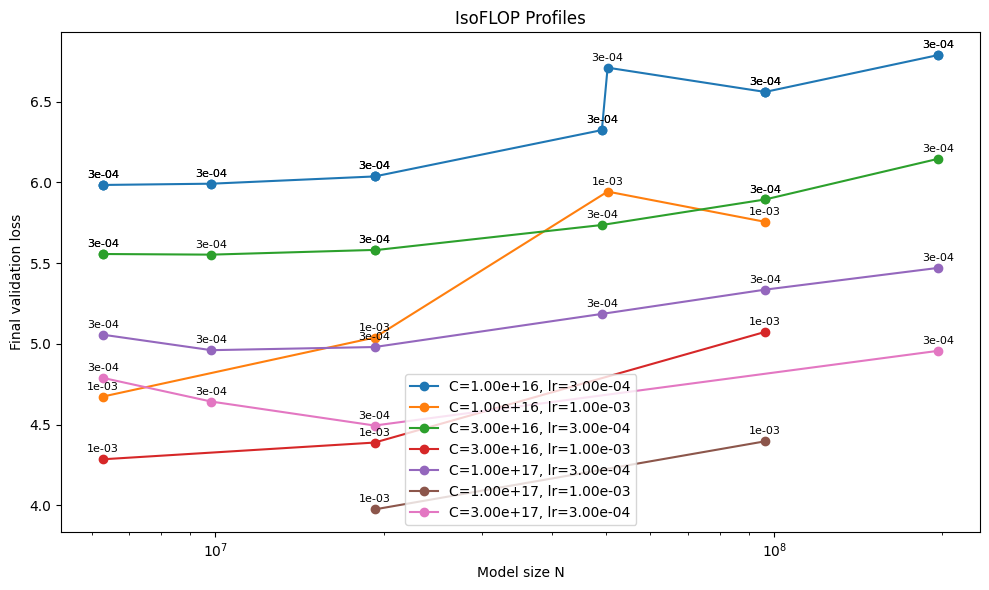

In [265]:
fig, ax = plt.subplots(figsize=(10, 6))
for (C_val, lr_val), group in df.groupby(["C_group", "lr"]):
    group = group.sort_values("N")
    label = f"C={C_val:.2e}, lr={lr_val:.2e}"
    ax.plot(group["N"], group["final_loss"], "o-", label=label)
    for i, row in group.iterrows():
        ax.annotate(
            f"{row['lr']:.0e}",
            (row["N"], row["final_loss"]),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=8,
        )

ax.set_xscale("log")
ax.set_xlabel("Model size N")
ax.set_ylabel("Final validation loss")
ax.set_title("IsoFLOP Profiles")
ax.legend()
plt.tight_layout()
plt.savefig("writeup/figures/isoflop_curve_old.png")
plt.show()

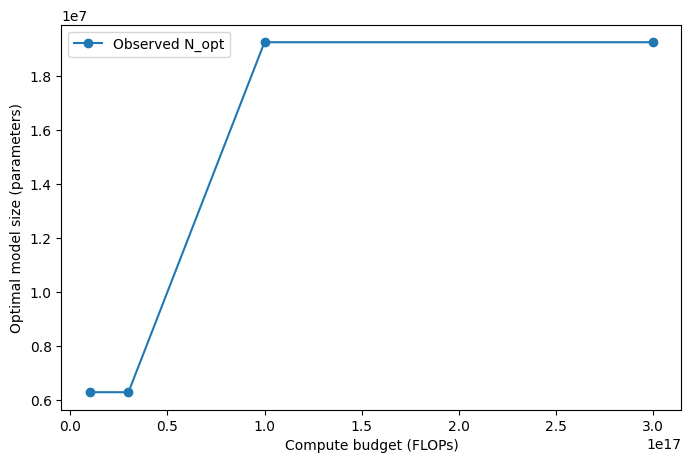

In [245]:
# main_lr = 3e-4
# df_main_lr = df[df["lr"] == main_lr]

optimal_points = []
for C_val, group in df.groupby("C_group"):
    best_run = group.loc[group["final_loss"].idxmin()]
    optimal_points.append((C_val, best_run["N"]))

optimal_points = sorted(optimal_points, key=lambda x: x[0])

C_vals = np.array([pt[0] for pt in optimal_points])
N_opts = np.array([pt[1] for pt in optimal_points])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(C_vals, N_opts, marker="o", label="Observed N_opt")
ax.set_xlabel("Compute budget (FLOPs)")
ax.set_ylabel("Optimal model size (parameters)")
ax.legend()
plt.show()

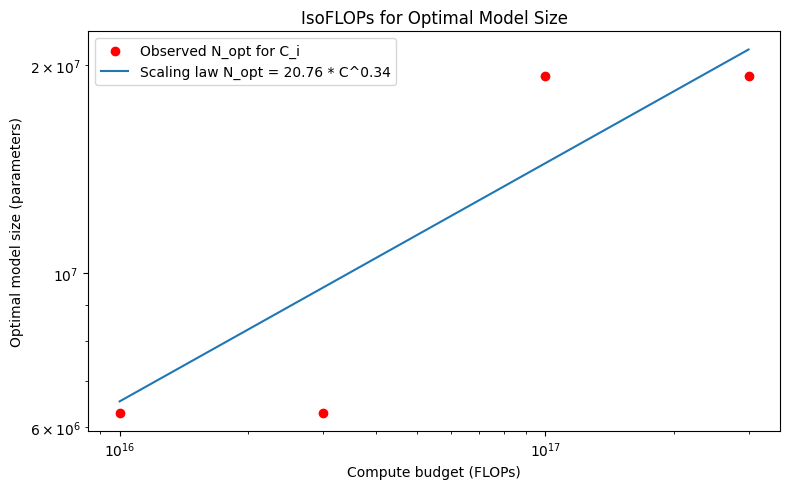

In [246]:
# Fit to power law N_opt = coeff * C^a
def power_law(C, coeff, a):
    return coeff * C**a

C_logscale = np.logspace(np.log10(C_vals[0]), np.log10(C_vals[-1]), 100)
(N_coeff, N_a), _ = curve_fit(power_law, C_vals, N_opts, maxfev=10000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(C_vals, N_opts, color="red", label="Observed N_opt for C_i")
ax.plot(C_logscale, power_law(C_logscale, N_coeff, N_a), label=f"Scaling law N_opt = {N_coeff:.2f} * C^{N_a:.2f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute budget (FLOPs)")
ax.set_ylabel("Optimal model size (parameters)")
ax.set_title("IsoFLOPs for Optimal Model Size")
ax.legend()
plt.tight_layout()
plt.show()

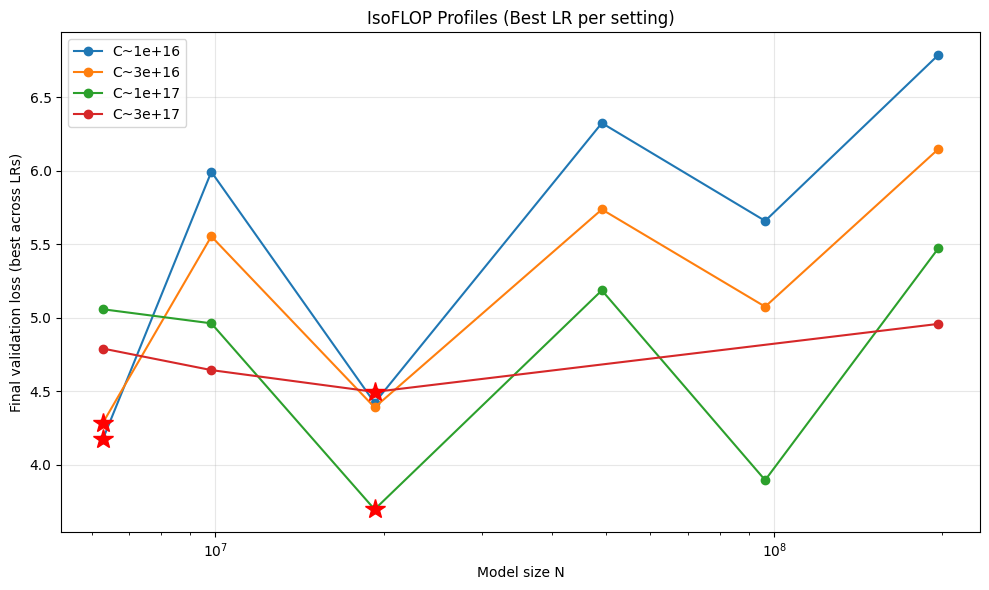


Optimal N per C level:
C~1.00e+16: N_opt=6.29e+06, lr=0.003, loss=4.1748
C~3.00e+16: N_opt=6.29e+06, lr=0.001, loss=4.2852
C~1.00e+17: N_opt=1.93e+07, lr=0.003, loss=3.6943
C~3.00e+17: N_opt=1.93e+07, lr=0.0003, loss=4.4941


In [257]:
experiments = list_experiments()

results = []
for exp in experiments:
    if exp.status.status_type == "completed":
        vals = compute_isoflops_vals(exp.training_config)
        results.append({
            "N": vals["N"],
            "D": vals["D"],
            "C": vals["C"],
            "lr": exp.training_config.optimizer_config.lr_scheduler.peak_value,
            "final_loss": exp.status.val_losses[-1],
        })

df = pd.DataFrame(results)
df = df[df["C"] > 5e15].copy()

# For each (C_group, N), keep only the best loss across all LRs
C_levels = [1e16, 3e16, 1e17, 3e17]

df["C_group"] = df["C"].apply(bucket_C)

# Key change: group by (C_group, N), take best loss across all LRs
best_per_size = df.loc[df.groupby(["C_group", "N"])["final_loss"].idxmin()]

# Plot IsoFLOP curves
fig, ax = plt.subplots(figsize=(10, 6))
for C_val, group in best_per_size.groupby("C_group"):
    group = group.sort_values("N")
    ax.plot(group["N"], group["final_loss"], "o-", label=f"C~{C_val:.0e}")
    best = group.loc[group["final_loss"].idxmin()]
    ax.plot(best["N"], best["final_loss"], "r*", markersize=15, zorder=5)

ax.set_xscale("log")
ax.set_xlabel("Model size N")
ax.set_ylabel("Final validation loss (best across LRs)")
ax.set_title("IsoFLOP Profiles (Best LR per setting)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print optimal N per C level
print("\nOptimal N per C level:")
for C_val, group in best_per_size.groupby("C_group"):
    best = group.loc[group["final_loss"].idxmin()]
    print(f"C~{C_val:.2e}: N_opt={best['N']:.2e}, lr={best['lr']}, loss={best['final_loss']:.4f}")

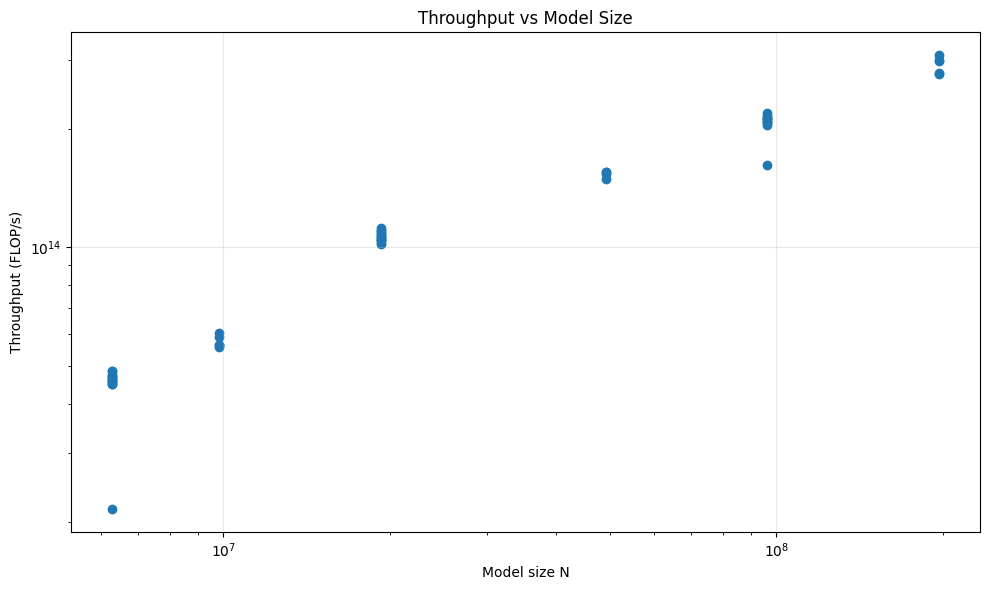

In [203]:
# Plot throughput vs N
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["N"], df["C"] / df["runtime"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Model size N")
ax.set_ylabel("Throughput (FLOP/s)")
ax.set_title("Throughput vs Model Size")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [119]:
# LR sweep: 3 model sizes x 4 learning rates at C=3e16

lr_values = [1e-3, 3e-4, 1e-4, 3e-5]

lr_sweep_sizes = {
    "5M":   {"hidden_size": 256,  "num_attention_heads": 4,  "num_hidden_layers": 8},
    "20M":  {"hidden_size": 448,  "num_attention_heads": 7,  "num_hidden_layers": 8},
    "100M": {"hidden_size": 896,  "num_attention_heads": 14, "num_hidden_layers": 10},
}

C_sweep = 3e16

submitted_lr = []
for name, size in lr_sweep_sizes.items():
    for lr in lr_values:
        N = 12 * size["num_hidden_layers"] * size["hidden_size"] ** 2
        D = C_sweep / (6 * N)
        chunk = 512 * 128 * 16
        total_tokens = max(chunk, round(D / chunk) * chunk)

        cfg = TrainingConfig(
            architecture_config=BasicTransformerConfig(
                **shared_arch,
                **size,
                num_key_value_heads=size["num_attention_heads"],
                intermediate_size=size["hidden_size"] * 4,
            ),
            optimizer_config=AdamWConfig(
                lr_scheduler=WarmupCosineDecay(
                    peak_value=lr,
                    final_lr_frac=0.1,
                    warmup_frac=0.05,
                    init_value=0.0,
                ),
                weight_decay=1e-2,
                beta1=0.9,
                beta2=0.95,
                eps=1e-8,
                eps_root=1e-8,
                grad_clip_norm=1.0,
            ),
            train_batch_size=128,
            val_batch_size=32,
            n_evals=16,
            total_train_tokens=total_tokens,
            max_runtime_seconds=1800,
            model_seed=0,
        )

        try:
            result = submit_experiment(cfg)
            print(f"{name}, lr={lr:.0e}: exp {result.experiment_id}, remaining={result.budget_summary.remaining_seconds:.0f}s")
            submitted_lr.append(result.experiment_id)
        except RuntimeError as e:
            if "409" in str(e):
                print(f"{name}, lr={lr:.0e}: already submitted")
            else:
                raise

5M, lr=1e-03: exp 1609, remaining=15846s
5M, lr=3e-04: already submitted
5M, lr=1e-04: exp 1610, remaining=14046s
5M, lr=3e-05: exp 1611, remaining=12246s
20M, lr=1e-03: exp 1612, remaining=10446s
20M, lr=3e-04: exp 1613, remaining=8646s
20M, lr=1e-04: exp 1614, remaining=6846s
20M, lr=3e-05: exp 1615, remaining=5046s
100M, lr=1e-03: exp 1616, remaining=3246s
100M, lr=3e-04: exp 1617, remaining=1446s


RuntimeError: 400 Client Error: Bad Request for url: http://hyperturing.stanford.edu:8000/submit
{"detail":{"message":"insufficient budget","budget_summary":{"used_seconds":41753.80919487679,"remaining_seconds":1446.1908051232094,"total_budget_seconds":43200.0}}}

In [195]:
lr_values_extended = [3e-3, 1e-3, 3e-4, 1e-4]

lr_sweep_sizes = {
    "5M":   {"hidden_size": 256,  "num_attention_heads": 4,  "num_hidden_layers": 8},
    "20M":  {"hidden_size": 448,  "num_attention_heads": 7,  "num_hidden_layers": 8},
    "100M": {"hidden_size": 896,  "num_attention_heads": 14, "num_hidden_layers": 10},
}

C_sweep = 1e16

submitted_lr2 = []
for name, size in lr_sweep_sizes.items():
    for lr in lr_values_extended:
        N = 12 * size["num_hidden_layers"] * size["hidden_size"] ** 2
        D = C_sweep / (6 * N)
        chunk = 512 * 128 * 16
        total_tokens = max(chunk, round(D / chunk) * chunk)

        cfg = TrainingConfig(
            architecture_config=BasicTransformerConfig(
                **shared_arch,
                **size,
                num_key_value_heads=size["num_attention_heads"],
                intermediate_size=size["hidden_size"] * 4,
            ),
            optimizer_config=AdamWConfig(
                lr_scheduler=WarmupCosineDecay(
                    peak_value=lr,
                    final_lr_frac=0.1,
                    warmup_frac=0.05,
                    init_value=0.0,
                ),
                weight_decay=1e-2,
                beta1=0.9,
                beta2=0.95,
                eps=1e-8,
                eps_root=1e-8,
                grad_clip_norm=1.0,
            ),
            train_batch_size=128,
            val_batch_size=32,
            n_evals=16,
            total_train_tokens=total_tokens,
            max_runtime_seconds=600,
            model_seed=0,
        )

        try:
            result = submit_experiment(cfg)
            print(f"{name}, lr={lr:.0e}: exp {result.experiment_id}, remaining={result.budget_summary.remaining_seconds:.0f}s")
            submitted_lr2.append(result.experiment_id)
        except RuntimeError as e:
            if "409" in str(e):
                print(f"{name}, lr={lr:.0e}: already submitted")
            else:
                raise

5M, lr=3e-03: already submitted
5M, lr=1e-03: already submitted
5M, lr=3e-04: already submitted
5M, lr=1e-04: already submitted
20M, lr=3e-03: already submitted
20M, lr=1e-03: already submitted
20M, lr=3e-04: already submitted
20M, lr=1e-04: already submitted
100M, lr=3e-03: already submitted
100M, lr=1e-03: already submitted
100M, lr=3e-04: already submitted
100M, lr=1e-04: already submitted


In [196]:
# After runs complete, analyze
experiments = list_experiments()

lr_results = []
for exp in experiments:
    if exp.status.status_type == "completed":
        vals = compute_isoflops_vals(exp.training_config)
        lr = exp.training_config.optimizer_config.lr_scheduler.peak_value
        lr_results.append({
            "N": vals["N"],
            "C": vals["C"],
            "lr": lr,
            "final_loss": exp.status.val_losses[-1],
        })

lr_df = pd.DataFrame(lr_results)

# For each model size, find best LR at each C level
print("Best LR by model size and C level:")
for N_val, group in lr_df.groupby("N"):
    for C_val, subgroup in group.groupby("C"):
        best = subgroup.loc[subgroup["final_loss"].idxmin()]
        print(f"  N={N_val:.2e}, C={C_val:.2e}: best_lr={best['lr']:.0e}, loss={best['final_loss']:.4f}")

Best LR by model size and C level:
  N=4.72e+06, C=1.19e+14: best_lr=3e-04, loss=8.5586
  N=6.29e+06, C=1.00e+16: best_lr=3e-03, loss=4.1748
  N=6.29e+06, C=3.00e+16: best_lr=1e-03, loss=4.2852
  N=6.29e+06, C=1.00e+17: best_lr=3e-04, loss=5.0566
  N=6.29e+06, C=3.00e+17: best_lr=3e-04, loss=4.7891
  N=9.83e+06, C=1.00e+16: best_lr=3e-04, loss=5.9922
  N=9.83e+06, C=3.00e+16: best_lr=3e-04, loss=5.5527
  N=9.83e+06, C=1.00e+17: best_lr=3e-04, loss=4.9609
  N=9.83e+06, C=3.00e+17: best_lr=3e-04, loss=4.6426
  N=1.93e+07, C=9.94e+15: best_lr=3e-03, loss=4.4199
  N=1.93e+07, C=2.99e+16: best_lr=1e-03, loss=4.3887
  N=1.93e+07, C=1.00e+17: best_lr=3e-04, loss=4.9805
  N=1.93e+07, C=3.00e+17: best_lr=3e-04, loss=4.4941
  N=2.17e+07, C=1.09e+15: best_lr=3e-04, loss=7.1895
  N=4.25e+07, C=1.07e+15: best_lr=3e-04, loss=7.3145
  N=4.92e+07, C=9.90e+15: best_lr=3e-04, loss=6.3242
  N=4.92e+07, C=3.00e+16: best_lr=3e-04, loss=5.7363
  N=4.92e+07, C=9.99e+16: best_lr=3e-04, loss=5.1855
  N=9.63e+0

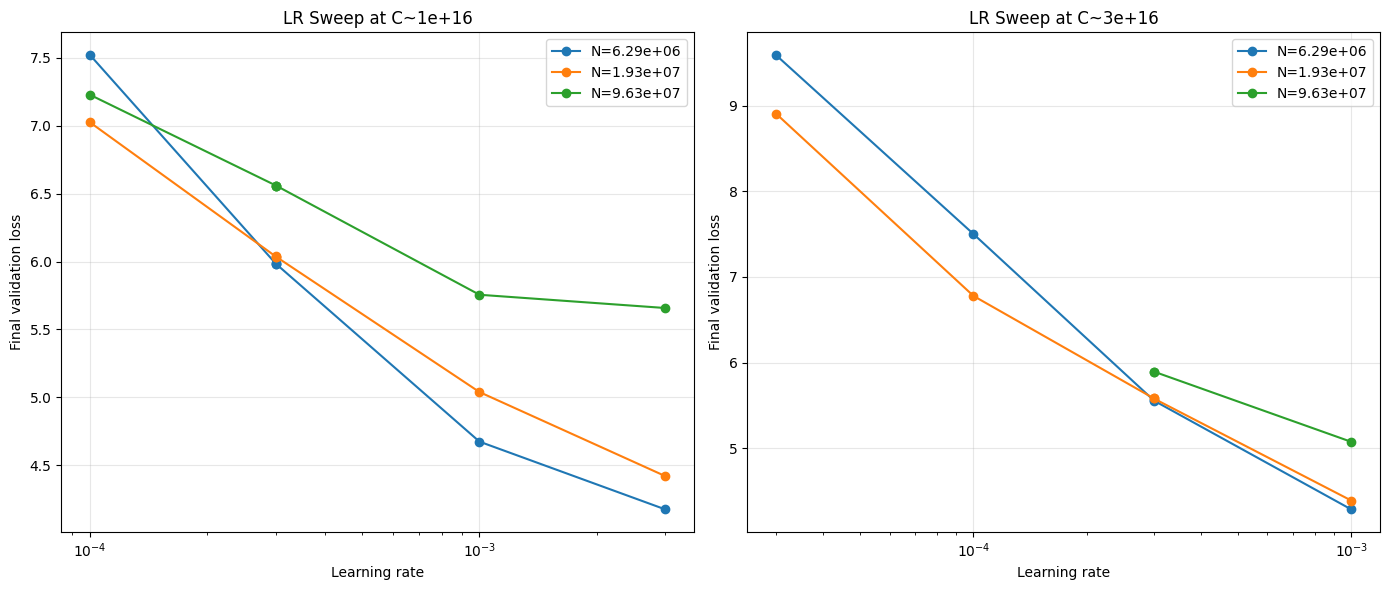


Best LR by model size and C level:
  C~1e+16, N=6.29e+06: best_lr=3e-03, loss=4.1748
  C~1e+16, N=1.93e+07: best_lr=3e-03, loss=4.4199
  C~1e+16, N=9.63e+07: best_lr=3e-03, loss=5.6582
  C~3e+16, N=6.29e+06: best_lr=1e-03, loss=4.2852
  C~3e+16, N=1.93e+07: best_lr=1e-03, loss=4.3887
  C~3e+16, N=9.63e+07: best_lr=1e-03, loss=5.0742


In [197]:
# Plot: for each C level, loss vs LR, one line per model size
C_targets = [1e16, 3e16]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, C_target in zip(axes, C_targets):
    # Filter to runs near this C level
    mask = (lr_df["C"] > C_target * 0.5) & (lr_df["C"] < C_target * 2)
    subset = lr_df[mask]
    
    # Only include runs where we have multiple LRs (i.e. sweep runs)
    for N_val, group in subset.groupby("N"):
        if len(group) < 3:
            continue
        group = group.sort_values("lr")
        ax.plot(group["lr"], group["final_loss"], "o-", label=f"N={N_val:.2e}")
    
    ax.set_xscale("log")
    ax.set_xlabel("Learning rate")
    ax.set_ylabel("Final validation loss")
    ax.set_title(f"LR Sweep at C~{C_target:.0e}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best LR per model size per C level
print("\nBest LR by model size and C level:")
for C_target in C_targets:
    mask = (lr_df["C"] > C_target * 0.5) & (lr_df["C"] < C_target * 2)
    subset = lr_df[mask]
    for N_val, group in subset.groupby("N"):
        if len(group) < 3:
            continue
        best = group.loc[group["final_loss"].idxmin()]
        print(f"  C~{C_target:.0e}, N={N_val:.2e}: best_lr={best['lr']:.0e}, loss={best['final_loss']:.4f}")

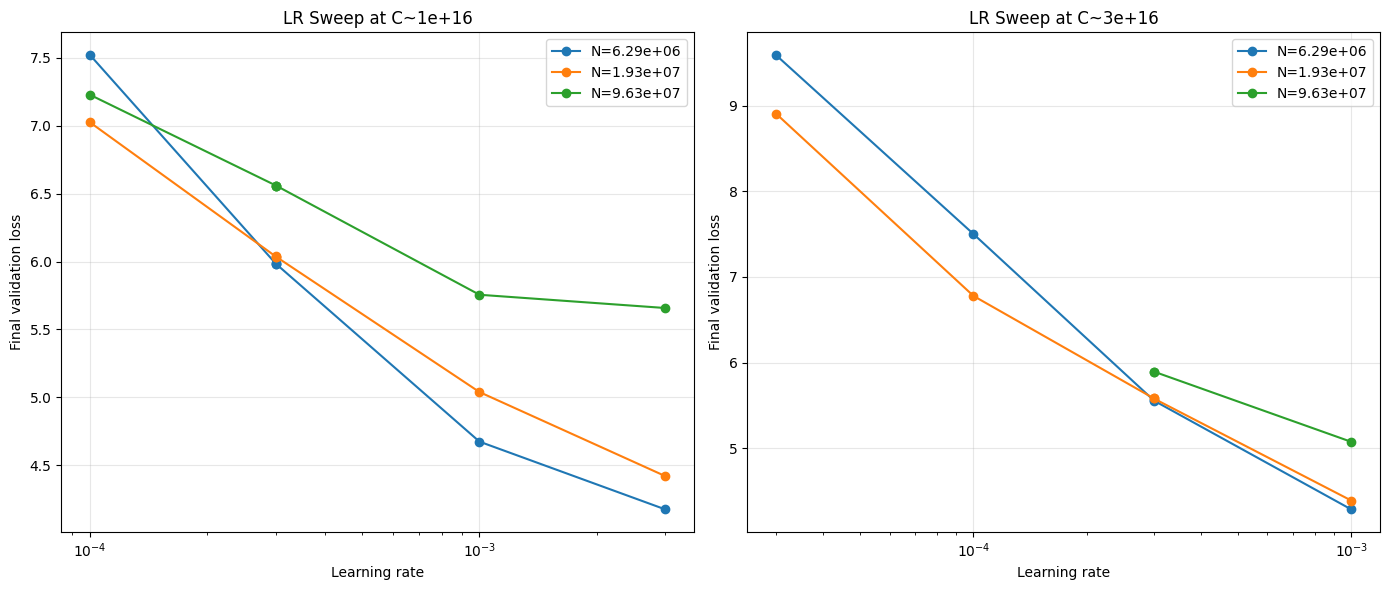


Best LR by model size and C level:
  C~1e+16, N=6.29e+06: best_lr=3e-03, loss=4.1748
  C~1e+16, N=1.93e+07: best_lr=3e-03, loss=4.4199
  C~1e+16, N=9.63e+07: best_lr=3e-03, loss=5.6582
  C~3e+16, N=6.29e+06: best_lr=1e-03, loss=4.2852
  C~3e+16, N=1.93e+07: best_lr=1e-03, loss=4.3887
  C~3e+16, N=9.63e+07: best_lr=1e-03, loss=5.0742


In [ ]:
# Plot: for each C level, loss vs LR, one line per model size
C_targets = [1e16, 3e16]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, C_target in zip(axes, C_targets):
    # Filter to runs near this C level
    mask = (lr_df["C"] > C_target * 0.5) & (lr_df["C"] < C_target * 2)
    subset = lr_df[mask]
    
    # Only include runs where we have multiple LRs (i.e. sweep runs)
    for N_val, group in subset.groupby("N"):
        if len(group) < 3:
            continue
        group = group.sort_values("lr")
        ax.plot(group["lr"], group["final_loss"], "o-", label=f"N={N_val:.2e}")
    
    ax.set_xscale("log")
    ax.set_xlabel("Learning rate")
    ax.set_ylabel("Final validation loss")
    ax.set_title(f"LR Sweep at C~{C_target:.0e}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best LR per model size per C level
print("\nBest LR by model size and C level:")
for C_target in C_targets:
    mask = (lr_df["C"] > C_target * 0.5) & (lr_df["C"] < C_target * 2)
    subset = lr_df[mask]
    for N_val, group in subset.groupby("N"):
        if len(group) < 3:
            continue
        best = group.loc[group["final_loss"].idxmin()]
        print(f"  C~{C_target:.0e}, N={N_val:.2e}: best_lr={best['lr']:.0e}, loss={best['final_loss']:.4f}")

        N           D                 C  total_steps  best_lr  best_loss
  6291456 265289728.0 10014351905783808       4048.0   0.0030   4.174805
  6291456 794820608.0 30003473298751488      12128.0   0.0010   4.285156
  9830400 169869312.0 10019299708108800       2592.0   0.0003   5.992188
 19267584  85983232.0  9940134870908928       1312.0   0.0030   4.419922
 19267584 258998272.0 29941625769689088       3952.0   0.0010   4.388672
 49152000  33554432.0  9895604649984000        512.0   0.0003   6.324219
 96337920  16777216.0  9697692556984320        256.0   0.0030   5.658203
 96337920  51380224.0 29699183455764480        784.0   0.0010   5.074219
196608000   8388608.0  9895604649984000        128.0   0.0003   6.787109


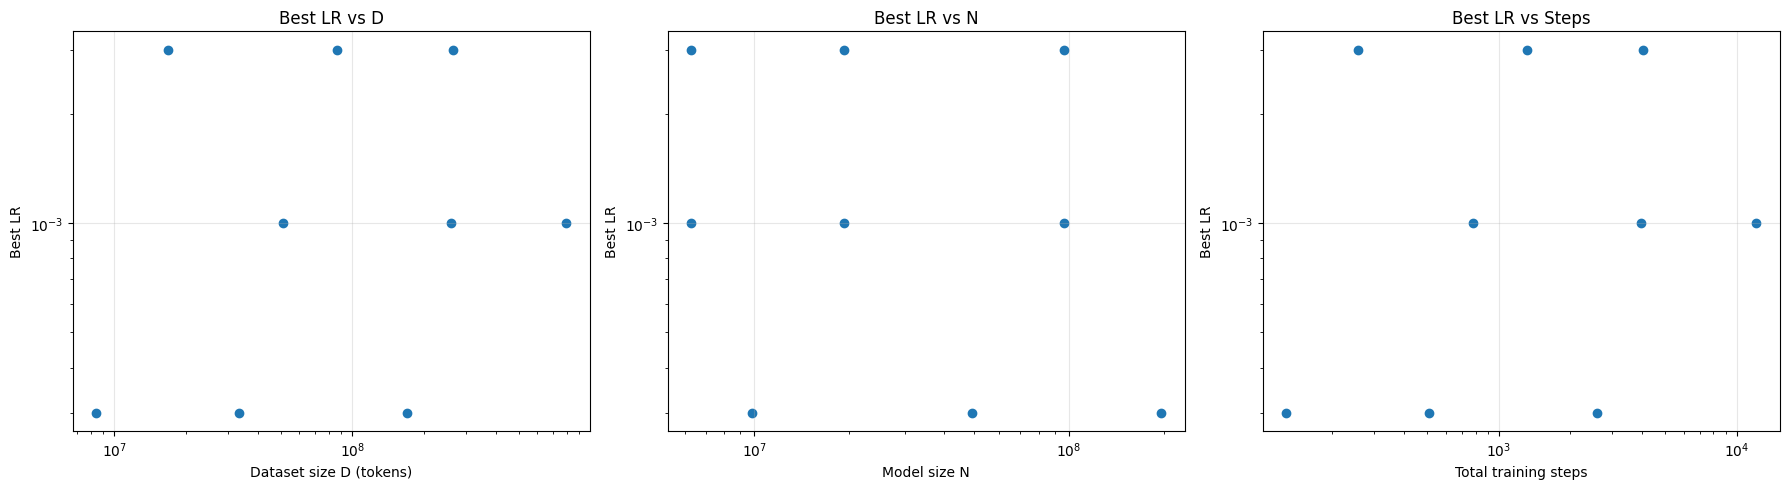


lr_opt = 7.97e-04 * D^0.0321
  D=1e+10: predicted lr=1.67e-03
  D=1e+11: predicted lr=1.80e-03
  D=1e+12: predicted lr=1.94e-03


In [198]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

experiments = list_experiments()

# Collect completed runs with LR info
lr_results = []
for exp in experiments:
    if exp.status.status_type == "completed":
        vals = compute_isoflops_vals(exp.training_config)
        lr = exp.training_config.optimizer_config.lr_scheduler.peak_value
        lr_results.append({
            "N": vals["N"],
            "D": vals["D"],
            "C": vals["C"],
            "lr": lr,
            "final_loss": exp.status.val_losses[-1],
            "total_steps": exp.training_config.total_train_tokens // (512 * exp.training_config.train_batch_size),
        })

lr_df = pd.DataFrame(lr_results)

# For each (N, C) combo that had multiple LRs, find the best
best_lrs = []
for (N_val, C_val), group in lr_df.groupby(["N", "C"]):
    if len(group) < 2:
        continue
    best = group.loc[group["final_loss"].idxmin()]
    best_lrs.append({
        "N": N_val,
        "D": best["D"],
        "C": C_val,
        "total_steps": best["total_steps"],
        "best_lr": best["lr"],
        "best_loss": best["final_loss"],
    })

best_lr_df = pd.DataFrame(best_lrs)
print(best_lr_df[["N", "D", "C", "total_steps", "best_lr", "best_loss"]].to_string(index=False))

# Plot best LR vs D
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# vs D
ax = axes[0]
ax.scatter(best_lr_df["D"], best_lr_df["best_lr"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Dataset size D (tokens)")
ax.set_ylabel("Best LR")
ax.set_title("Best LR vs D")
ax.grid(True, alpha=0.3)

# vs N
ax = axes[1]
ax.scatter(best_lr_df["N"], best_lr_df["best_lr"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Model size N")
ax.set_ylabel("Best LR")
ax.set_title("Best LR vs N")
ax.grid(True, alpha=0.3)

# vs total_steps
ax = axes[2]
ax.scatter(best_lr_df["total_steps"], best_lr_df["best_lr"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total training steps")
ax.set_ylabel("Best LR")
ax.set_title("Best LR vs Steps")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Fit power law: lr_opt = k * D^(-alpha)
def power_law(x, k, a):
    return k * x**a

try:
    popt, _ = curve_fit(power_law, best_lr_df["D"].values, best_lr_df["best_lr"].values, p0=[1, -0.3])
    print(f"\nlr_opt = {popt[0]:.2e} * D^{popt[1]:.4f}")
    
    # Predict LR for large D values
    for D_target in [1e10, 1e11, 1e12]:
        pred_lr = power_law(D_target, *popt)
        print(f"  D={D_target:.0e}: predicted lr={pred_lr:.2e}")
except:
    print("Power law fit failed — might need more data points")

In [211]:
C_sweep = 1e17

lr_sweep_sizes = {
    "5M":   {"hidden_size": 256,  "num_attention_heads": 4,  "num_hidden_layers": 8},
    "20M":  {"hidden_size": 448,  "num_attention_heads": 7,  "num_hidden_layers": 8},
    "100M": {"hidden_size": 896,  "num_attention_heads": 14, "num_hidden_layers": 10},
}

lr_values = [3e-3, 1e-3]

submitted = []
for name, size in lr_sweep_sizes.items():
    for lr in lr_values:
        N = 12 * size["num_hidden_layers"] * size["hidden_size"] ** 2
        D = C_sweep / (6 * N)
        chunk = 512 * 128 * 16
        total_tokens = max(chunk, round(D / chunk) * chunk)

        cfg = TrainingConfig(
            architecture_config=BasicTransformerConfig(
                **shared_arch,
                **size,
                num_key_value_heads=size["num_attention_heads"],
                intermediate_size=size["hidden_size"] * 4,
            ),
            optimizer_config=AdamWConfig(
                lr_scheduler=WarmupCosineDecay(
                    peak_value=lr,
                    final_lr_frac=0.1,
                    warmup_frac=0.05,
                    init_value=0.0,
                ),
                weight_decay=1e-2,
                beta1=0.9,
                beta2=0.95,
                eps=1e-8,
                eps_root=1e-8,
                grad_clip_norm=1.0,
            ),
            train_batch_size=128,
            val_batch_size=32,
            n_evals=16,
            total_train_tokens=total_tokens,
            max_runtime_seconds=1200,
            model_seed=0,
        )

        try:
            result = submit_experiment(cfg)
            print(f"{name}, lr={lr:.0e}: exp {result.experiment_id}, remaining={result.budget_summary.remaining_seconds:.0f}s")
            submitted.append(result.experiment_id)
        except RuntimeError as e:
            if "409" in str(e):
                print(f"{name}, lr={lr:.0e}: already submitted")
            else:
                raise

5M, lr=3e-03: exp 2086, remaining=10957s
5M, lr=1e-03: exp 2087, remaining=9757s
20M, lr=3e-03: exp 2088, remaining=8557s
20M, lr=1e-03: exp 2089, remaining=7357s
100M, lr=3e-03: exp 2090, remaining=6157s
100M, lr=1e-03: exp 2091, remaining=4957s


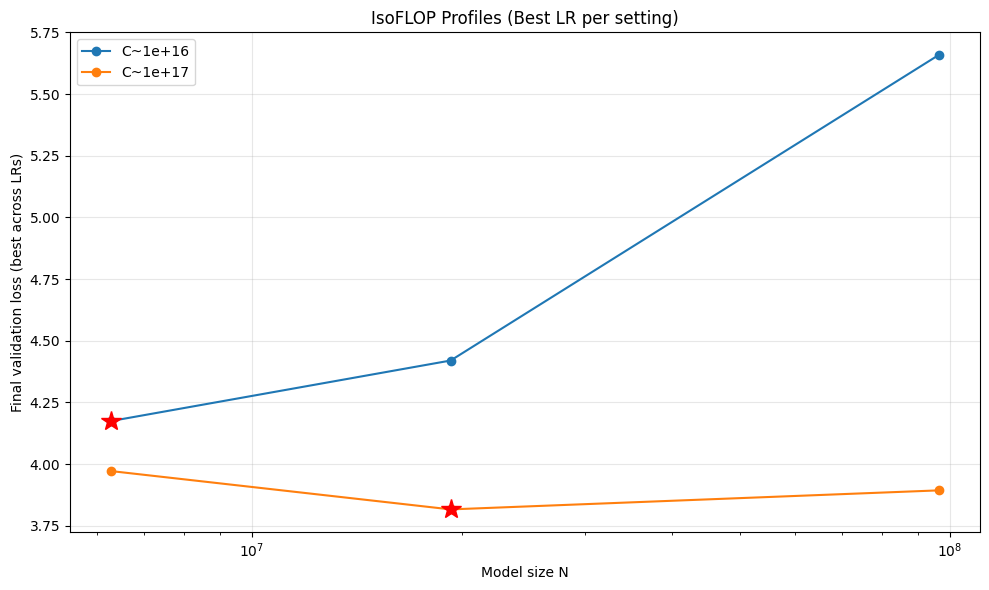

C~1e+16: N_opt=6.29e+06, D=2.65e+08, lr=0.003, loss=4.1748
C~1e+17: N_opt=1.93e+07, D=8.65e+08, lr=0.003, loss=3.8164

N_opt = 1.05e-01 * C^0.4861
D_opt = 1.59e+00 * C^0.5139
Throughput = 1.00e+00 * N^0.3000

=== 48-hour prediction ===
Target C: 6.14e+05
Optimal N: 6.84e+01
Optimal D: 1.50e+03
D/N ratio: 21.9
Estimated throughput: 3.55e+00 FLOP/s


/var/folders/0s/74hhldz55tlb6w2zb69fcrb40000gn/T/ipykernel_4407/1888904643.py:60: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_N, _ = curve_fit(power_law, c_values, n_opt_values, p0=[1, 0.5])
/var/folders/0s/74hhldz55tlb6w2zb69fcrb40000gn/T/ipykernel_4407/1888904643.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_D, _ = curve_fit(power_law, c_values, d_opt_values, p0=[1, 0.5])
/var/folders/0s/74hhldz55tlb6w2zb69fcrb40000gn/T/ipykernel_4407/1888904643.py:69: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_tp, _ = curve_fit(power_law, tp_by_N["N"].values, tp_by_N["throughput"].values, p0=[1, 0.3])


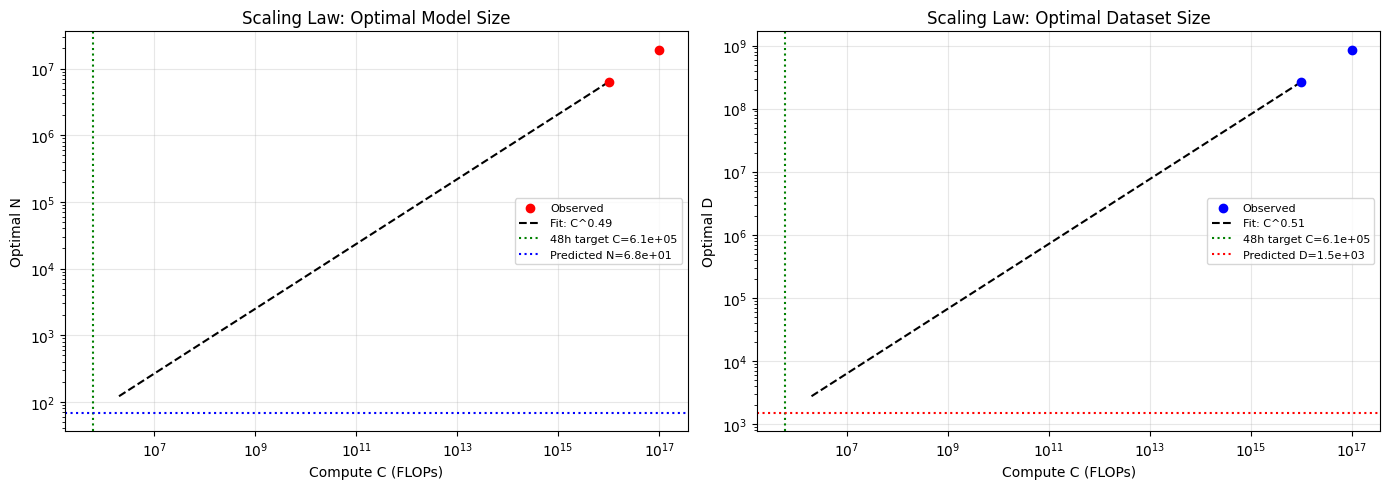

In [224]:
experiments = list_experiments()

# Collect completed runs
results = []
for exp in experiments:
    vals = compute_isoflops_vals(exp.training_config)
    results.append({
        "experiment_id": exp.experiment_id,
        "N": vals["N"],
        "D": vals["D"],
        "C": vals["C"],
        "final_loss": exp.status.val_losses[-1],
        "runtime": exp.status.used_runtime_seconds if exp.status.status_type == "completed" else None,
        "lr": exp.training_config.optimizer_config.lr_scheduler.peak_value
    })

df = pd.DataFrame(results)
df = df[df["C"] > 5e15].copy()

main_lr = 3e-3
df = df[df["lr"] == main_lr]
df["C_group"] = df["C"].apply(bucket_C)

# For each (C_group, N), take the best loss across all LRs
best_per_size = df.loc[df.groupby(["C_group", "N"])["final_loss"].idxmin()]

# Plot IsoFLOP curves
fig, ax = plt.subplots(figsize=(10, 6))
for C_val, group in best_per_size.groupby("C_group"):
    group = group.sort_values("N")
    ax.plot(group["N"], group["final_loss"], "o-", label=f"C~{C_val:.0e}")
    best = group.loc[group["final_loss"].idxmin()]
    ax.plot(best["N"], best["final_loss"], "r*", markersize=15, zorder=5)
ax.set_xscale("log")
ax.set_xlabel("Model size N")
ax.set_ylabel("Final validation loss (best across LRs)")
ax.set_title("IsoFLOP Profiles (Best LR per setting)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find N_opt per C level
c_values = []
n_opt_values = []
for C_val, group in best_per_size.groupby("C_group"):
    best = group.loc[group["final_loss"].idxmin()]
    c_values.append(C_val)
    n_opt_values.append(best["N"])
    print(f"C~{C_val:.0e}: N_opt={best['N']:.2e}, D={best['D']:.2e}, lr={best['lr']}, loss={best['final_loss']:.4f}")

c_values = np.array(c_values)
n_opt_values = np.array(n_opt_values)
d_opt_values = np.array([C / (6 * N) for C, N in zip(c_values, n_opt_values)])

# Fit power laws
def power_law(C, k, a):
    return k * C**a

popt_N, _ = curve_fit(power_law, c_values, n_opt_values, p0=[1, 0.5])
popt_D, _ = curve_fit(power_law, c_values, d_opt_values, p0=[1, 0.5])
print(f"\nN_opt = {popt_N[0]:.2e} * C^{popt_N[1]:.4f}")
print(f"D_opt = {popt_D[0]:.2e} * C^{popt_D[1]:.4f}")

# Fit throughput: use all completed runs
df["throughput"] = df["C"] / df["runtime"]
# Fit throughput vs N as power law
tp_by_N = df.groupby("N")["throughput"].median().reset_index()
popt_tp, _ = curve_fit(power_law, tp_by_N["N"].values, tp_by_N["throughput"].values, p0=[1, 0.3])
print(f"Throughput = {popt_tp[0]:.2e} * N^{popt_tp[1]:.4f}")

# Estimate target C for 48 hours iteratively
target_seconds = 48 * 3600
# Start with a guess
N_guess = 1e8
for i in range(10):
    tp = power_law(N_guess, *popt_tp)
    target_C = tp * target_seconds
    N_guess = power_law(target_C, *popt_N)

pred_N = N_guess
pred_tp = power_law(pred_N, *popt_tp)
pred_C = pred_tp * target_seconds
pred_D = pred_C / (6 * pred_N)

print(f"\n=== 48-hour prediction ===")
print(f"Target C: {pred_C:.2e}")
print(f"Optimal N: {pred_N:.2e}")
print(f"Optimal D: {pred_D:.2e}")
print(f"D/N ratio: {pred_D/pred_N:.1f}")
print(f"Estimated throughput: {pred_tp:.2e} FLOP/s")

# Plot scaling laws with extrapolation
C_extrap = np.logspace(np.log10(min(c_values)), np.log10(pred_C) + 0.5, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(c_values, n_opt_values, color="red", zorder=5, label="Observed")
ax.plot(C_extrap, power_law(C_extrap, *popt_N), "k--", label=f"Fit: C^{popt_N[1]:.2f}")
ax.axvline(pred_C, color="green", ls=":", label=f"48h target C={pred_C:.1e}")
ax.axhline(pred_N, color="blue", ls=":", label=f"Predicted N={pred_N:.1e}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute C (FLOPs)")
ax.set_ylabel("Optimal N")
ax.set_title("Scaling Law: Optimal Model Size")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(c_values, d_opt_values, color="blue", zorder=5, label="Observed")
ax.plot(C_extrap, power_law(C_extrap, *popt_D), "k--", label=f"Fit: C^{popt_D[1]:.2f}")
ax.axvline(pred_C, color="green", ls=":", label=f"48h target C={pred_C:.1e}")
ax.axhline(pred_D, color="red", ls=":", label=f"Predicted D={pred_D:.1e}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute C (FLOPs)")
ax.set_ylabel("Optimal D")
ax.set_title("Scaling Law: Optimal Dataset Size")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [221]:
# First, let's just look at the throughput data
print("=== Raw throughput data ===")
for _, row in df.sort_values("N").iterrows():
    if row["runtime"] is not None and row["runtime"] > 0:
        tp = row["C"] / row["runtime"]
        print(f"N={row['N']:.2e}, C={row['C']:.2e}, runtime={row['runtime']:.1f}s, throughput={tp:.2e}")

# The issue is probably that curve_fit needs better initial params
# Let's fit in log space instead
df_tp = df[df["runtime"].notna() & (df["runtime"] > 0)].copy()
df_tp["throughput"] = df_tp["C"] / df_tp["runtime"]
tp_by_N = df_tp.groupby("N")["throughput"].median().reset_index()

# Fit in log space: log(tp) = log(k) + a * log(N)
log_N = np.log(tp_by_N["N"].values)
log_tp = np.log(tp_by_N["throughput"].values)
coeffs = np.polyfit(log_N, log_tp, 1)
a_tp = coeffs[0]
k_tp = np.exp(coeffs[1])
print(f"\nThroughput = {k_tp:.2e} * N^{a_tp:.4f}")

# Verify it looks right
for N_test in [1e7, 5e7, 1e8, 5e8]:
    print(f"  N={N_test:.0e}: predicted throughput = {k_tp * N_test**a_tp:.2e} FLOP/s")

# Now redo the 48-hour prediction with fixed throughput
def get_throughput(N):
    return k_tp * N**a_tp

target_seconds = 48 * 3600
N_guess = 1e8
for i in range(20):
    tp = get_throughput(N_guess)
    target_C = tp * target_seconds
    N_guess = power_law(target_C, *popt_N)

pred_N = N_guess
pred_tp = get_throughput(pred_N)
pred_C = pred_tp * target_seconds
pred_D = pred_C / (6 * pred_N)

print(f"\n=== 48-hour prediction (fixed throughput) ===")
print(f"Target C:       {pred_C:.2e} FLOPs")
print(f"Optimal N:      {pred_N:.2e} parameters")
print(f"Optimal D:      {pred_D:.2e} tokens")
print(f"D/N ratio:      {pred_D/pred_N:.1f}")
print(f"Throughput:     {pred_tp:.2e} FLOP/s")

=== Raw throughput data ===
N=6.29e+06, C=3.00e+16, runtime=639.5s, throughput=4.69e+13
N=6.29e+06, C=1.00e+16, runtime=223.2s, throughput=4.49e+13
N=6.29e+06, C=3.00e+17, runtime=6560.1s, throughput=4.57e+13
N=6.29e+06, C=1.00e+17, runtime=2211.0s, throughput=4.52e+13
N=6.29e+06, C=3.00e+16, runtime=632.5s, throughput=4.74e+13
N=6.29e+06, C=1.00e+16, runtime=215.5s, throughput=4.65e+13
N=6.29e+06, C=1.00e+16, runtime=206.3s, throughput=4.85e+13
N=9.83e+06, C=1.00e+16, runtime=177.8s, throughput=5.64e+13
N=9.83e+06, C=1.00e+17, runtime=1654.0s, throughput=6.05e+13
N=9.83e+06, C=3.00e+16, runtime=531.6s, throughput=5.64e+13
N=9.83e+06, C=1.00e+16, runtime=179.6s, throughput=5.58e+13
N=9.83e+06, C=3.00e+17, runtime=5069.8s, throughput=5.92e+13
N=1.93e+07, C=9.94e+15, runtime=97.3s, throughput=1.02e+14
N=1.93e+07, C=2.99e+16, runtime=272.3s, throughput=1.10e+14
N=1.93e+07, C=3.00e+17, runtime=2882.8s, throughput=1.04e+14
N=1.93e+07, C=2.99e+16, runtime=277.1s, throughput=1.08e+14
N=1.93e+

In [222]:
# We only need N_opt scaling law + throughput scaling law
# D is just: D = C / (6 * N)

print(f"N_opt = {popt_N[0]:.2e} * C^{popt_N[1]:.4f}")
print(f"Throughput = {k_tp:.2e} * N^{a_tp:.4f}")

# Iteratively solve for 48 hours
target_seconds = 48 * 3600
N_guess = 1e8
for i in range(20):
    tp = k_tp * N_guess**a_tp
    target_C = tp * target_seconds
    N_guess = power_law(target_C, *popt_N)

pred_N = N_guess
pred_tp = k_tp * pred_N**a_tp
pred_C = pred_tp * target_seconds
pred_D = pred_C / (6 * pred_N)

print(f"\n=== 48-hour prediction ===")
print(f"Target C:       {pred_C:.2e} FLOPs")
print(f"Optimal N:      {pred_N:.2e} parameters")
print(f"Optimal D:      {pred_D:.2e} tokens (back-calculated from C=6ND)")
print(f"D/N ratio:      {pred_D/pred_N:.1f}")
print(f"Throughput:     {pred_tp:.2e} FLOP/s")
print(f"Runtime check:  {pred_C/pred_tp/3600:.1f} hours")

N_opt = 2.36e+01 * C^0.3368
Throughput = 1.01e+10 * N^0.5417

=== 48-hour prediction ===
Target C:       3.57e+19 FLOPs
Optimal N:      9.11e+07 parameters
Optimal D:      6.54e+10 tokens (back-calculated from C=6ND)
D/N ratio:      718.3
Throughput:     2.07e+14 FLOP/s
Runtime check:  48.0 hours


In [231]:
experiments = list_experiments()

# Collect everything
results = []
for exp in experiments:
    vals = compute_isoflops_vals(exp.training_config)
    results.append({
        "id": exp.experiment_id,
        "N": vals["N"],
        "D": vals["D"],
        "C": vals["C"],
        "lr": exp.training_config.optimizer_config.lr_scheduler.peak_value,
        "loss": exp.status.val_losses[-1],
        "runtime": exp.status.used_runtime_seconds if exp.status.status_type == "completed" else None,
        "hidden": exp.training_config.architecture_config.hidden_size,
        "layers": exp.training_config.architecture_config.num_hidden_layers,
    })

df = pd.DataFrame(results)

# Print everything sorted
print(df[["id","N","D","C","lr","loss","runtime"]].sort_values(["lr","C","N"]).to_string(index=False))

  id         N          D                  C      lr     loss     runtime
1615  19267584  258998272  29941625769689088 0.00003 8.906250  268.168291
1611   6291456  794820608  30003473298751488 0.00003 9.589844  620.638784
2068  96337920   16777216   9697692556984320 0.00010 7.228516   46.192442
2064  19267584   85983232   9940134870908928 0.00010 7.025391   92.882515
2060   6291456  265289728  10014351905783808 0.00010 7.521484  218.403627
1614  19267584  258998272  29941625769689088 0.00010 6.777344  269.949193
1610   6291456  794820608  30003473298751488 0.00010 7.500000 1394.187538
1227   4718592    4194304    118747255799808 0.00030 8.558594    2.645500
1228  42467328    4194304   1068725302198272 0.00030 7.314453    5.879855
1213  21676032    8388608   1090990412660736 0.00030 7.189453   11.025441
1229 150994944    4194304   3799912185593856 0.00030 7.179688   13.191278
1251  96337920   16777216   9697692556984320 0.00030 6.560547   46.796907
1260  96337920   16777216   9697692556

In [ ]:
submitted = []

In [251]:
C_sweep = 1e14

model_sizes = {
    "5M":   {"hidden_size": 256,  "num_attention_heads": 4,  "num_hidden_layers": 8},
    "10M":  {"hidden_size": 320,  "num_attention_heads": 5,  "num_hidden_layers": 8},
    "20M":  {"hidden_size": 448,  "num_attention_heads": 7,  "num_hidden_layers": 8},
    "50M":  {"hidden_size": 640,  "num_attention_heads": 10, "num_hidden_layers": 10},
    "100M": {"hidden_size": 896,  "num_attention_heads": 14, "num_hidden_layers": 10},
    "200M": {"hidden_size": 1280, "num_attention_heads": 20, "num_hidden_layers": 10},
}

lr_values = [3e-3]

for name, size in model_sizes.items():
    N = 12 * size["num_hidden_layers"] * size["hidden_size"] ** 2
    D = C_sweep / (6 * N)
    chunk = 512 * 128 * 16
    total_tokens = max(chunk, round(D / chunk) * chunk)

    cfg = TrainingConfig(
        architecture_config=BasicTransformerConfig(
            **shared_arch,
            **size,
            num_key_value_heads=size["num_attention_heads"],
            intermediate_size=size["hidden_size"] * 4,
        ),
        optimizer_config=AdamWConfig(
            lr_scheduler=WarmupCosineDecay(
                peak_value=lr,
                final_lr_frac=0.1,
                warmup_frac=0.05,
                init_value=0.0,
            ),
            weight_decay=1e-2,
            beta1=0.9,
            beta2=0.95,
            eps=1e-8,
            eps_root=1e-8,
            grad_clip_norm=1.0,
        ),
        train_batch_size=128,
        val_batch_size=32,
        n_evals=16,
        total_train_tokens=total_tokens,
        max_runtime_seconds=300,
        model_seed=0,
    )

    try:
        result = submit_experiment(cfg)
        print(f"{name}, lr={lr:.0e}: exp {result.experiment_id}, remaining={result.budget_summary.remaining_seconds:.0f}s")
        submitted.append(result.experiment_id)
    except RuntimeError as e:
        if "409" in str(e):
            print(f"{name}, lr={lr:.0e}: already submitted")
        else:
            raise
    submitted.append(result.experiment_id)

5M, lr=1e-03: already submitted
10M, lr=1e-03: already submitted
20M, lr=1e-03: already submitted
50M, lr=1e-03: already submitted
100M, lr=1e-03: already submitted
200M, lr=1e-03: already submitted


In [252]:
submitted

[4258,
 4259,
 4260,
 4261,
 4262,
 4264,
 4266,
 4267,
 4268,
 4269,
 4270,
 4270,
 4270,
 4270,
 4270,
 4270,
 4270]

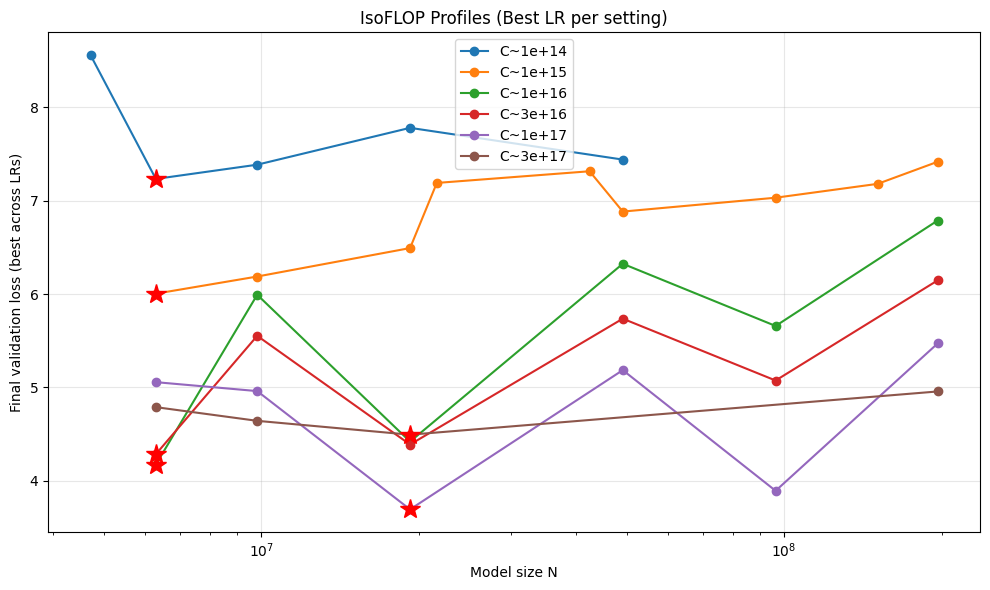


Optimal N per C level:
C~1.00e+14: N_opt=6.29e+06, lr=0.001, loss=7.2324
C~1.00e+15: N_opt=6.29e+06, lr=0.001, loss=6.0039
C~1.00e+16: N_opt=6.29e+06, lr=0.003, loss=4.1748
C~3.00e+16: N_opt=6.29e+06, lr=0.001, loss=4.2852
C~1.00e+17: N_opt=1.93e+07, lr=0.003, loss=3.6943
C~3.00e+17: N_opt=1.93e+07, lr=0.0003, loss=4.4941


In [260]:
experiments = list_experiments()

results = []
for exp in experiments:
    if exp.status.status_type == "completed":
        vals = compute_isoflops_vals(exp.training_config)

        results.append({
            "N": vals["N"],
            "D": vals["D"],
            "C": vals["C"],
            "lr": exp.training_config.optimizer_config.lr_scheduler.peak_value,
            "final_loss": exp.status.val_losses[-1],
        })

df = pd.DataFrame(results)

# For each (C_group, N), keep only the best loss across all LRs
C_levels = [1e14, 1e15, 1e16, 3e16, 1e17, 3e17]

df["C_group"] = df["C"].apply(bucket_C)

# Key change: group by (C_group, N), take best loss across all LRs
best_per_size = df.loc[df.groupby(["C_group", "N"])["final_loss"].idxmin()]

# Plot IsoFLOP curves
fig, ax = plt.subplots(figsize=(10, 6))
for C_val, group in best_per_size.groupby("C_group"):
    group = group.sort_values("N")
    ax.plot(group["N"], group["final_loss"], "o-", label=f"C~{C_val:.0e}")
    best = group.loc[group["final_loss"].idxmin()]
    ax.plot(best["N"], best["final_loss"], "r*", markersize=15, zorder=5)

ax.set_xscale("log")
ax.set_xlabel("Model size N")
ax.set_ylabel("Final validation loss (best across LRs)")
ax.set_title("IsoFLOP Profiles (Best LR per setting)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print optimal N per C level
print("\nOptimal N per C level:")
for C_val, group in best_per_size.groupby("C_group"):
    best = group.loc[group["final_loss"].idxmin()]
    print(f"C~{C_val:.2e}: N_opt={best['N']:.2e}, lr={best['lr']}, loss={best['final_loss']:.4f}")